In [132]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

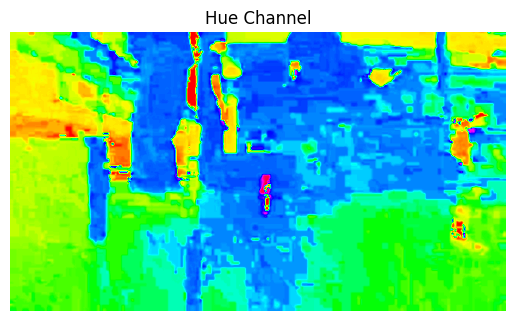

In [133]:
img = cv2.imread("captured_image_3.jpg")
image_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
h,s,v=cv2.split(image_hsv)
h_blur = cv2.GaussianBlur(h, (7, 7), 0)
plt.imshow(h_blur,cmap='hsv')
plt.title('Hue Channel')
plt.axis('off')
plt.show()


Text(0.5, 1.0, 'Binary Image')

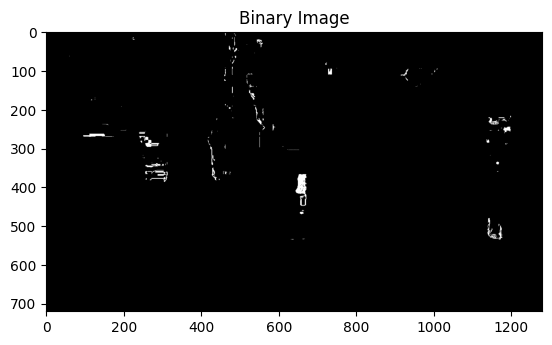

In [134]:
img_binary = ((h > 0) & (h < 10)) | ((h > 140) & (h < 180))
plt.imshow(img_binary, cmap='gray')
plt.title('Binary Image')

Text(0.5, 1.0, 'Binary Image')

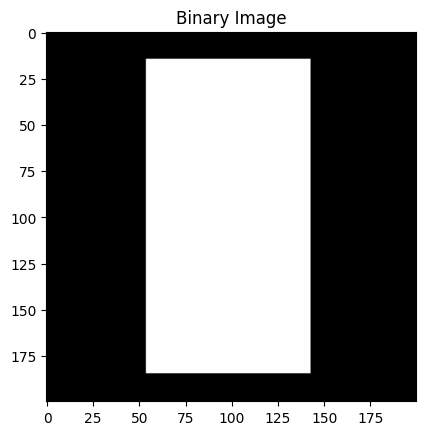

In [135]:
templat1=cv2.imread("bounding_box_1.jpg")
template_hsv=cv2.cvtColor(templat1,cv2.COLOR_BGR2HSV)
template_h,template_s,template_v_1=cv2.split(template_hsv)
template_binary1 = (template_v_1 > 100)
plt.imshow(template_binary1, cmap='gray')
plt.title('Binary Image')

templat2=cv2.imread("bounding_box_2.jpg")
template_hsv=cv2.cvtColor(templat2,cv2.COLOR_BGR2HSV)
template_h,template_s,template_v_2=cv2.split(template_hsv)
template_binary2 = (template_v_2 > 100)
plt.imshow(template_binary2, cmap='gray')
plt.title('Binary Image')   

templat3=cv2.imread("bounding_box_3.jpg")
template_hsv=cv2.cvtColor(templat3,cv2.COLOR_BGR2HSV)
template_h,template_s,template_v_3=cv2.split(template_hsv)
template_binary3 = (template_v_3 > 100)
plt.imshow(template_binary1, cmap='gray')
plt.title('Binary Image')

Text(0.5, 1.0, 'Binary Image')

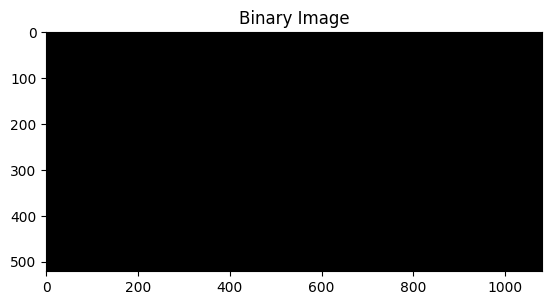

In [136]:
# Convert boolean mask to uint8 (0 or 255)

# Convert boolean masks to uint8 (0 or 255)
img_binary_uint8 = img_binary.astype(np.uint8) * 255
template_binary_uint8_1 = template_binary1.astype(np.uint8) * 255
template_binary_uint8_2 = template_binary2.astype(np.uint8) * 255
template_binary_uint8_3 = template_binary3.astype(np.uint8) * 255
value = cv2.matchTemplate(img_binary_uint8, template_binary_uint8_1, cv2.TM_CCOEFF_NORMED)
value2 = cv2.matchTemplate(img_binary_uint8, template_binary_uint8_2, cv2.TM_CCOEFF_NORMED)
value3 = cv2.matchTemplate(img_binary_uint8, template_binary_uint8_3, cv2.TM_CCOEFF_NORMED)

img_binary_va1 = (value > 0.3)
img_binary_va2 = (value2 > 0.3)
img_binary_va3 = (value3 > 0.3)

plt.imshow(img_binary_va1, cmap='gray')
plt.title('Binary Image')

In [137]:
min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(value)
min_val2, max_val2, min_loc2, max_loc2 = cv2.minMaxLoc(value2)
min_val3, max_val3, min_loc3, max_loc3 = cv2.minMaxLoc(value3)
top, bottom, left, right = 0, 0, 0, 0
if max(max_val, max_val2, max_val3) == max_val:
    top_template = max_loc
    template_h, template_w = template_binary_uint8_1.shape
    max_val = max_val
    bottom_template = (top_template[0] + template_w, top_template[1] + template_h)
    img_binary_scan=img_binary[top_template[1]:bottom_template[1], top_template[0]:bottom_template[0]]
    for n,i in enumerate(img_binary_scan):
        if any(i)==True and top==0:
            top=n
        if top!=0 and any(i)==False:
            bottom=n
            break
    for n,j in enumerate(img_binary_scan.T):
        if any(j)==True and top==0:
            left=n
        if left!=0 and any(j)==False:
            right=n
            break
    top_right = (max_loc[0] + top, max_loc[1]+bottom)
    bottom_right = (bottom_template[0] + right, bottom_template[1] + left)
elif max(max_val, max_val2, max_val3) == max_val2:
    top_template = max_loc2
    template_h, template_w = template_binary_uint8_2.shape
    max_val = max_val2
    bottom_template = (top_template[0] + template_w, top_template[1] + template_h)
    img_binary_scan=img_binary[top_template[1]:bottom_template[1], top_template[0]:bottom_template[0]]
    for n,i in enumerate(img_binary_scan):
        if any(i)==True and top==0:
            top=n
        if top!=0 and any(i)==False:
            bottom=n
            break
    for n,j in enumerate(img_binary_scan.T):
        if any(j)==True and top==0:
            left=n
            print(1)
        if left!=0 and any(j)==False:
            right=n
            break
    top_right = (max_loc2[0] + top, max_loc2[1]+bottom)
    bottom_right = (bottom_template[0] + right, bottom_template[1] + left)
else:
    top_template = max_loc3
    template_h, template_w = template_binary_uint8_3.shape
    max_val = max_val3
    bottom_template = (top_template[0] + template_w, top_template[1] + template_h)
    img_binary_scan=img_binary[top_template[1]:bottom_template[1], top_template[0]:bottom_template[0]]
    for n,i in enumerate(img_binary_scan):
        if any(i)==True and top==0:
            top=n
        if top!=0 and any(i)==False:
            bottom=n
            break
    for n,j in enumerate(img_binary_scan.T):
        if any(j)==True and top==0:
            left=n
            
        if left!=0 and any(j)==False:
            right=n
            break
    top_right = (max_loc3[0] + top, max_loc3[1]+bottom)
    bottom_right = (bottom_template[0] + right, bottom_template[1] + left)

# print(top, bottom, left, right)
# cv2.rectangle(img, top_right, bottom_right, 255, 2) # Draw rectangle on original image
# plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)) # Display the result
# plt.show()
# print(max_val)
